In [1]:
import os
import re
import pandas as pd
import glob

# Define your local folder path where the Excel files are stored
folder_path = "services"  # Change this to your actual path
pattern = os.path.join(folder_path, "services_*.xlsx")

# Load files matching the pattern
xlsx_files = sorted(glob.glob(pattern), key=lambda f: int(re.search(r"services_(\d+)_", os.path.basename(f)).group(1)))

services = []

# Process each file
for filepath in xlsx_files:
    filename = os.path.basename(filepath)

    match = re.match(r"services_(\d+)_(\d+)\.xlsx", filename)
    if not match:
        print(f"Filename format invalid: {filename} (skipped)")
        continue

    index = int(match.group(1))
    limit = float(match.group(2))

    df = pd.read_excel(filepath)
    service_tuple = (df, limit)
    services.append(service_tuple)

    globals()[f"service_{index}"] = service_tuple
    print(f"Loaded service_{index}: {df.shape[0]} rows, limit = {limit}")

# Summary
print("\nSummary of All Loaded Services")
for i, (df, limit) in enumerate(services, start=1):
    print(f"service_{i} → {df.shape[0]} rows, limit = {limit}")


Loaded service_1: 2 rows, limit = 400000.0
Loaded service_2: 7 rows, limit = 1500000.0
Loaded service_3: 18 rows, limit = 600000.0
Loaded service_4: 19 rows, limit = 200000.0
Loaded service_5: 41 rows, limit = 30000.0
Loaded service_6: 75 rows, limit = 300000.0
Loaded service_7: 128 rows, limit = 100000.0
Loaded service_8: 962 rows, limit = 100000.0
Loaded service_9: 36 rows, limit = 100000.0
Loaded service_10: 143 rows, limit = 500000.0
Loaded service_11: 146 rows, limit = 60000.0

Summary of All Loaded Services
service_1 → 2 rows, limit = 400000.0
service_2 → 7 rows, limit = 1500000.0
service_3 → 18 rows, limit = 600000.0
service_4 → 19 rows, limit = 200000.0
service_5 → 41 rows, limit = 30000.0
service_6 → 75 rows, limit = 300000.0
service_7 → 128 rows, limit = 100000.0
service_8 → 962 rows, limit = 100000.0
service_9 → 36 rows, limit = 100000.0
service_10 → 143 rows, limit = 500000.0
service_11 → 146 rows, limit = 60000.0


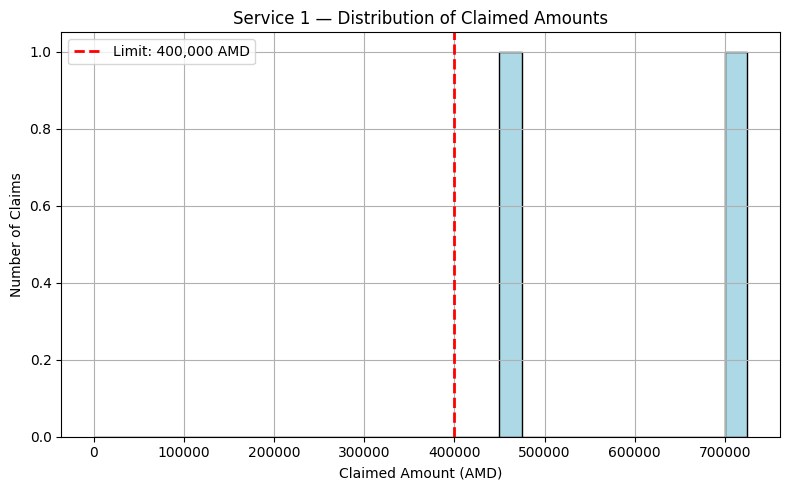

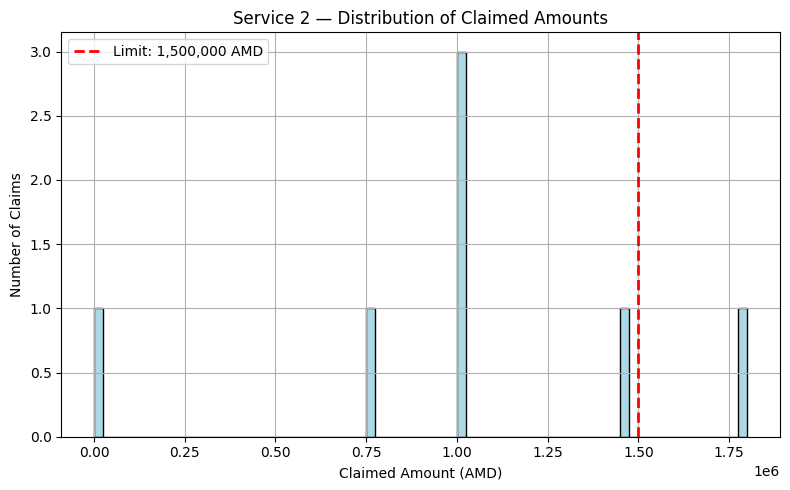

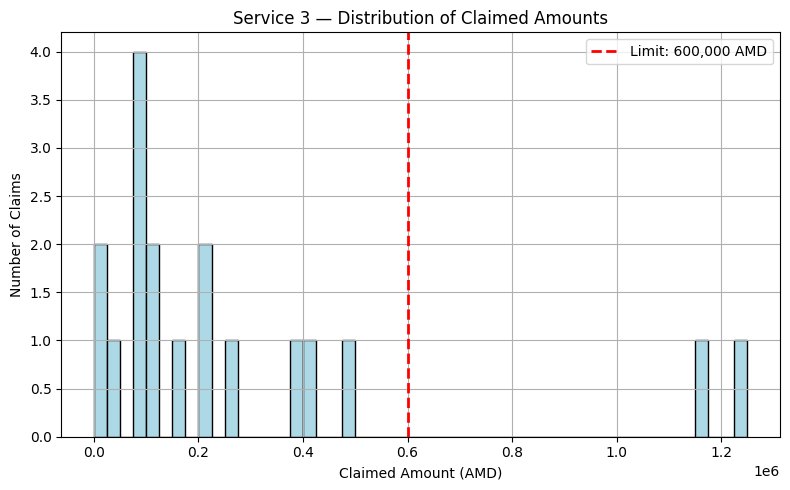

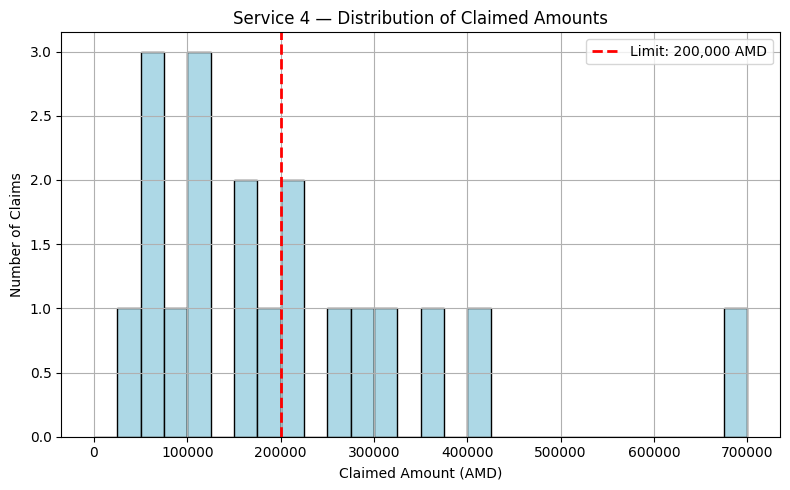

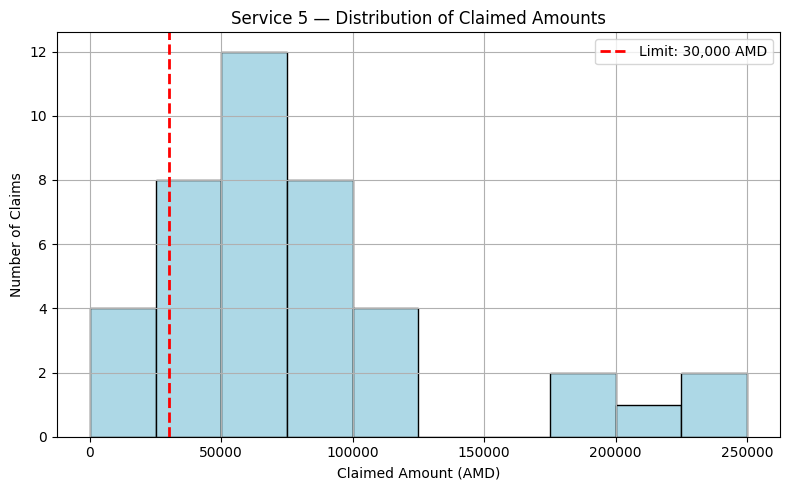

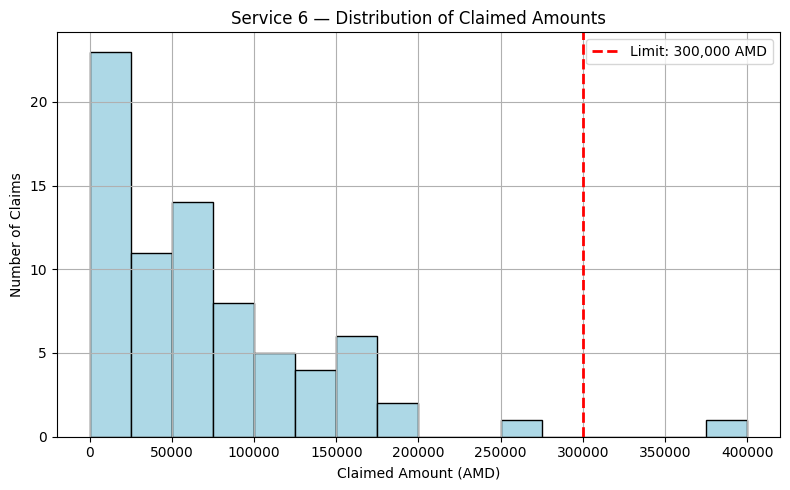

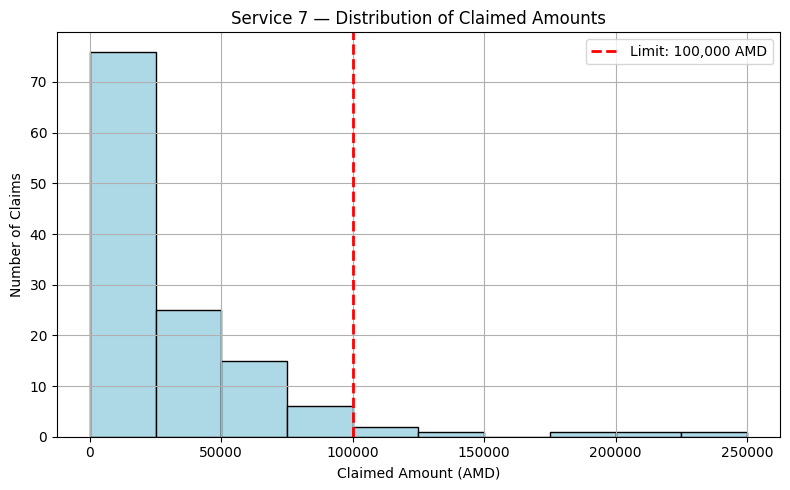

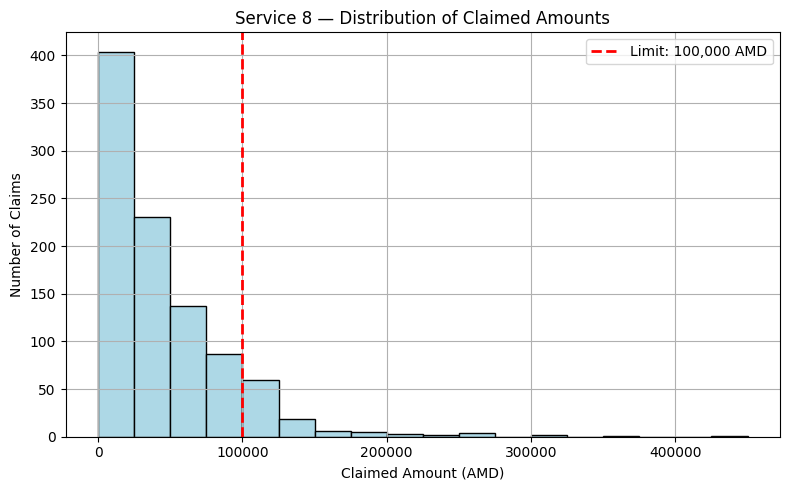

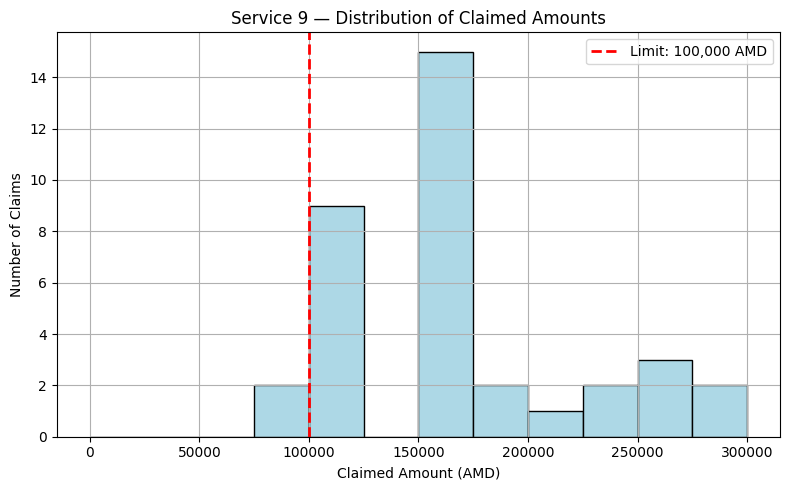

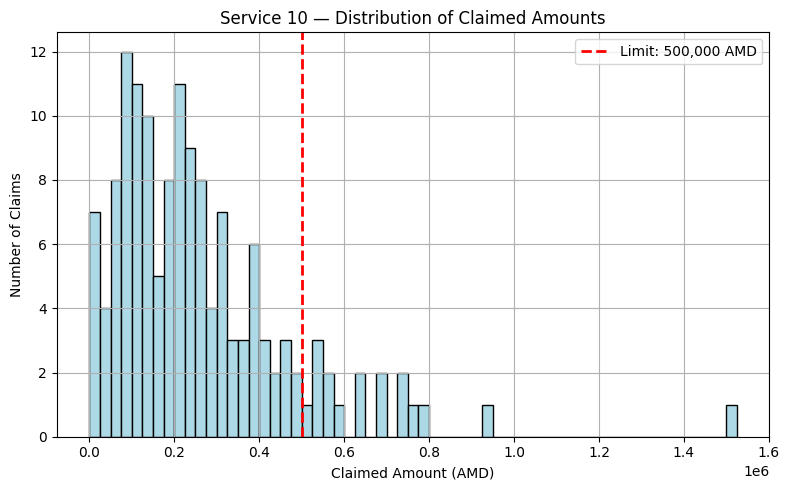

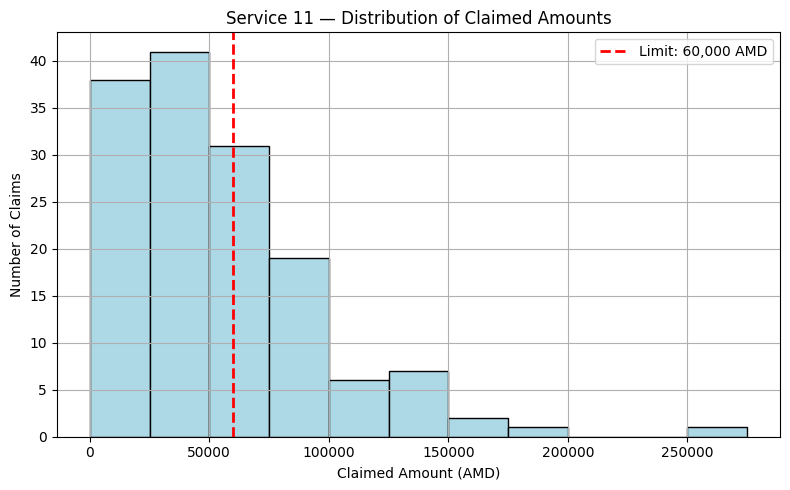

In [2]:
import matplotlib.pyplot as plt
import numpy as np

bin_size = 25000  # You can adjust this
num_services = len(services)

for i, (df, limit) in enumerate(services, start=1):
    claims = df["ClaimedAmount"]
    max_claim = claims.max()
    bins = np.arange(0, max_claim + bin_size, bin_size)

    plt.figure(figsize=(8, 5))
    plt.hist(claims, bins=bins, edgecolor='black', color='lightblue')

    plt.axvline(limit, color='red', linestyle='--', linewidth=2, label=f"Limit: {int(limit):,} AMD")
    plt.title(f"Service {i} — Distribution of Claimed Amounts")
    plt.xlabel("Claimed Amount (AMD)")
    plt.ylabel("Number of Claims")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [5]:
relative_edges = np.linspace(0, 2.0, 15)  # 15 bins, 0% to 200% of limit

binnings = []  # List to store (bin_edges, bin_centers) for each service

for i, (df, limit) in enumerate(services, start=1):
    bins = relative_edges * limit
    centers = 0.5 * (bins[:-1] + bins[1:])
    binnings.append((bins, centers))

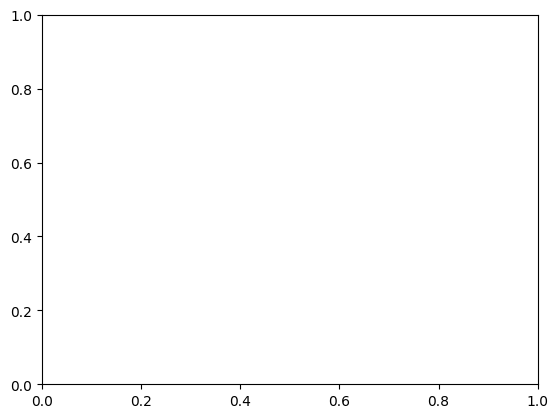

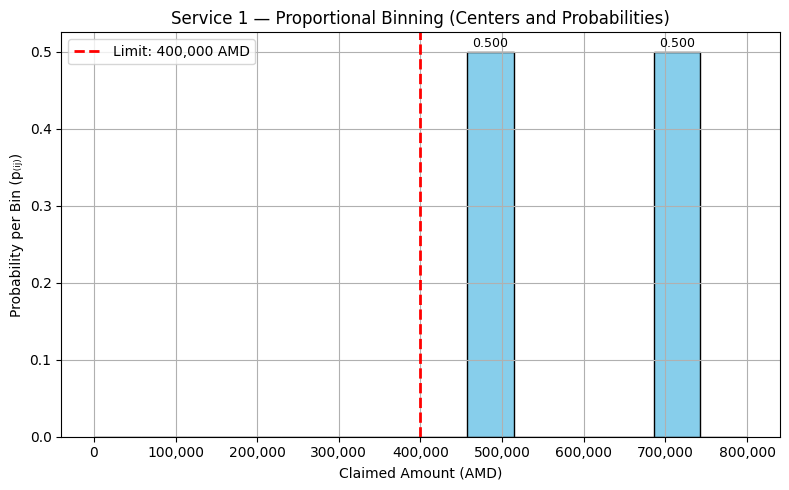

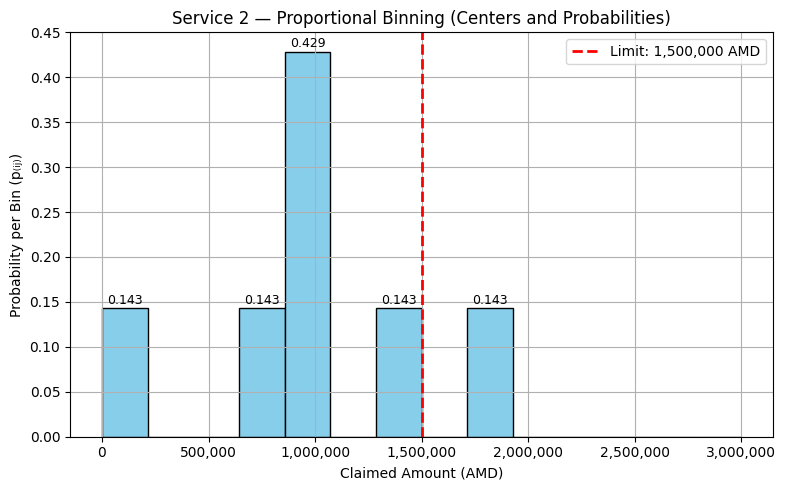

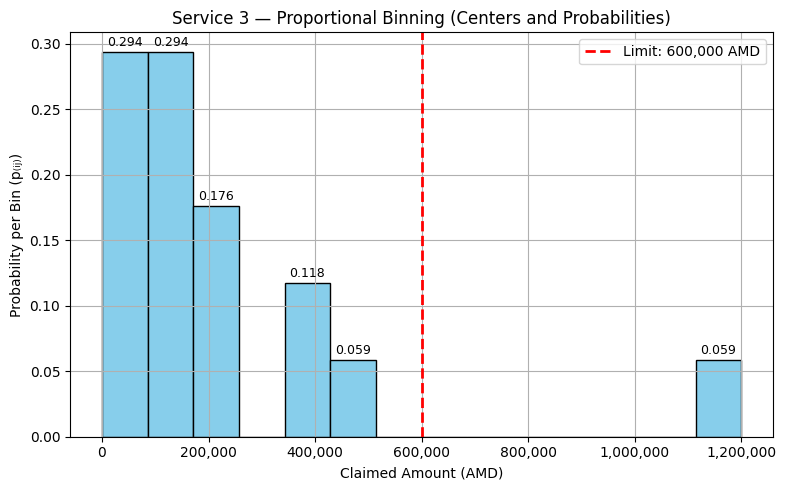

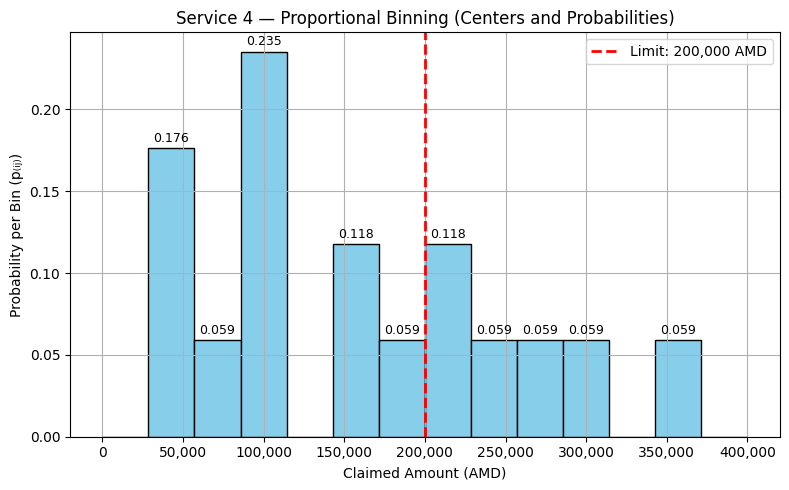

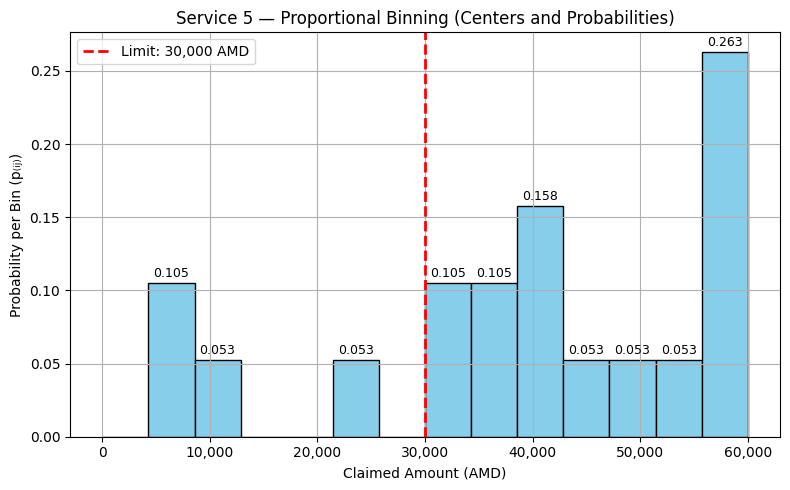

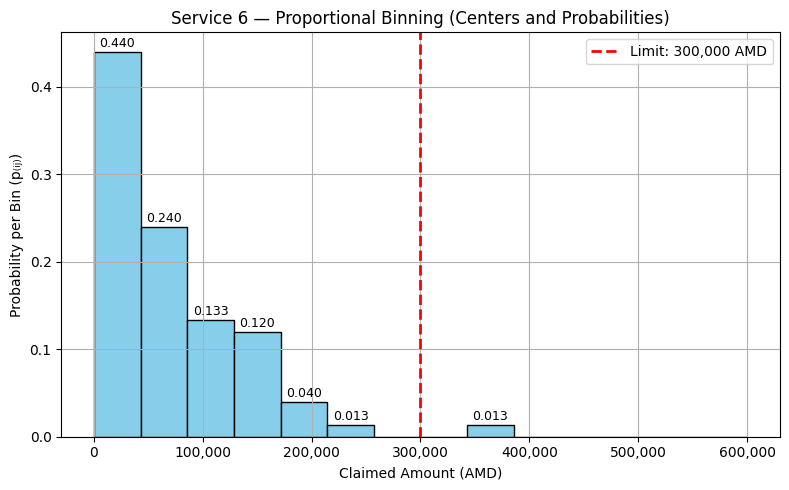

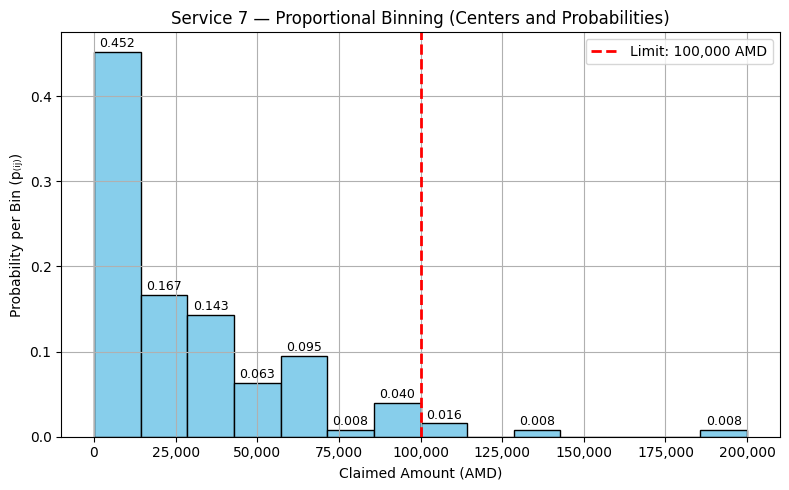

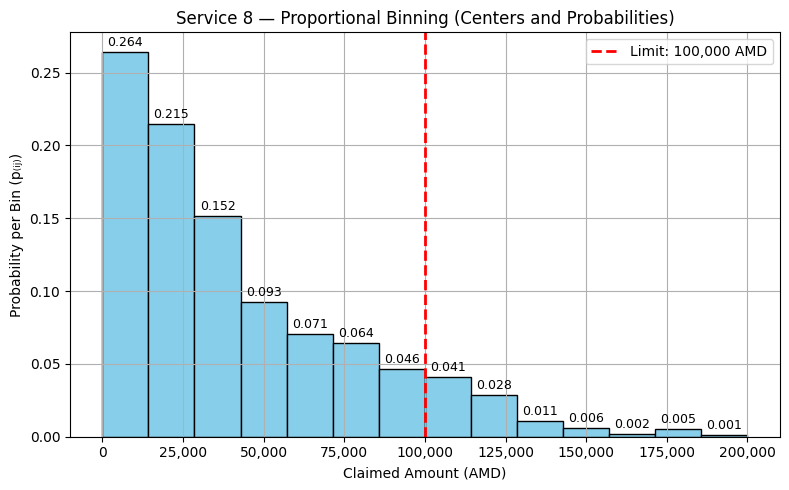

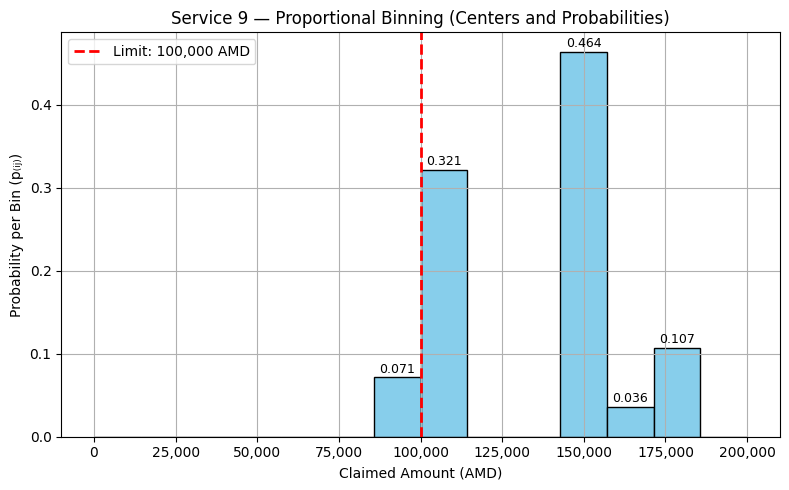

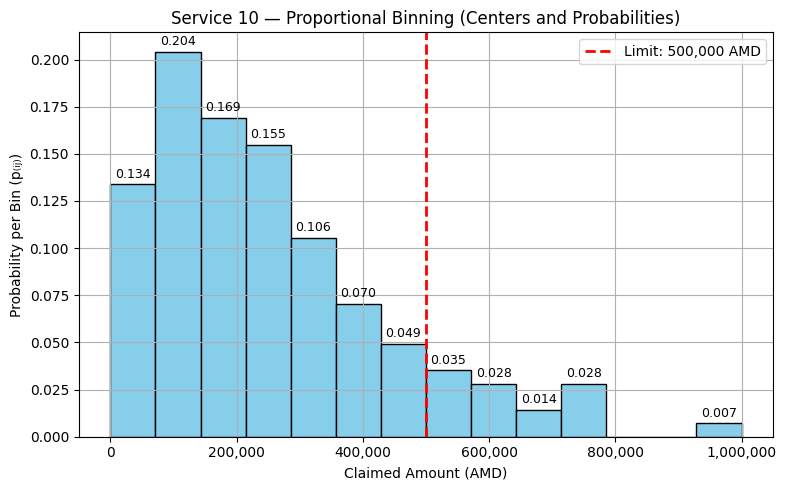

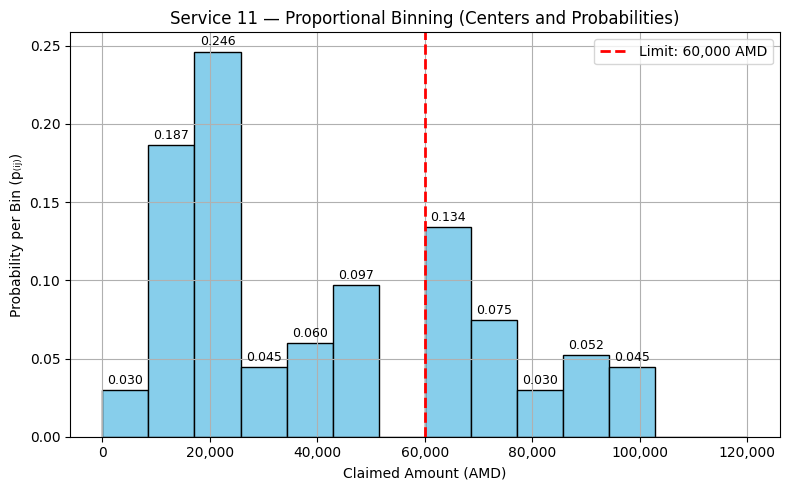

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Disable scientific notation
plt.ticklabel_format(style='plain', axis='x')

# Set number formatting globally
import matplotlib.ticker as mtick
from matplotlib.ticker import FuncFormatter

def comma_fmt(x, pos):
    return f'{int(x):,}'

formatter = FuncFormatter(comma_fmt)

# Binning setup
relative_edges = np.linspace(0, 2.0, 15)
binning_info = []

for i, (df, limit) in enumerate(services, start=1):
    claims = df["ClaimedAmount"]
    bins = relative_edges * limit
    bin_counts, bin_edges = np.histogram(claims, bins=bins)
    total_claims = bin_counts.sum()

    p_ij = bin_counts / total_claims
    c_ij = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    binning_info.append({
        "service_index": i,
        "limit": limit,
        "centers": c_ij,
        "probs": p_ij
    })

    # Plot
    plt.figure(figsize=(8, 5))
    bar_container = plt.bar(c_ij, p_ij, width=np.diff(bins), align='center', edgecolor='black', color='skyblue')

    # Format x-axis with commas
    plt.gca().xaxis.set_major_formatter(formatter)

    # Add limit line
    plt.axvline(limit, color='red', linestyle='--', linewidth=2, label=f"Limit: {int(limit):,} AMD")

    # Annotate p_ij on top of bars (horizontally)
    for bar, p in zip(bar_container, p_ij):
        if p > 0:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width() / 2, height + 0.002, f"{p:.3f}",
                     ha='center', va='bottom', fontsize=9, rotation=0)

    plt.title(f"Service {i} — Proportional Binning (Centers and Probabilities)")
    plt.xlabel("Claimed Amount (AMD)")
    plt.ylabel("Probability per Bin (p₍ᵢⱼ₎)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [7]:
# This will store all inputs in a list of dicts (one per service)
optimization_inputs = []

for info in binning_info:
    limit = info["limit"]
    centers = info["centers"]
    probs = info["probs"]

    # Filter out zero-probability bins to make optimization cleaner
    nonzero_mask = probs > 0
    c_ij = centers[nonzero_mask]
    p_ij = probs[nonzero_mask]

    # Store clean input
    optimization_inputs.append({
        "limit": limit,
        "c_ij": c_ij,
        "p_ij": p_ij
    })


In [8]:
import pickle

# Save the object locally
with open("optimization_inputs.pkl", "wb") as f:
    pickle.dump(optimization_inputs, f)

print("Saved as optimization_inputs.pkl in the current directory.")

Saved as optimization_inputs.pkl in the current directory.
